# Example: Singular Value Decomposition of a Grayscale Image
In this example, students will explore singular value decomposition (SVD) applied to an image. [Singular value decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition) is used in many applications, such as image and data compression, signal processing, and machine learning. SVD factors a matrix into a canonical form composed of an orthogonal matrix, a diagonal matrix, and another orthogonal matrix.

> __Learning Objectives__
>
> By the end of this activity, you should be able to:
> * __Decompose__ a grayscale image using singular value decomposition and understand what this mathematical technique reveals about the structure of data. You'll learn how SVD breaks down complex information into simpler, ranked components that capture different amounts of detail.
> * __Reconstruct__ the original image from its SVD components, and see how using only the top few singular values and their corresponding vectors can still yield a good approximation of the original image. This will illustrate the concept of data compression and how much information is retained or lost when reducing dimensionality.
> * __Relate__ the rank of a matrix to the number of rank-one frames used to build it. You'll check that adding up the first few frames of the image produces a matrix whose rank equals the number of frames added.

This example builds on [the L7a lecture](CHEME-5800-L7a-Lecture-SVDAndDataReduction-Fall-2026.ipynb). There, the Eckart–Young theorem says that keeping only the largest singular values gives the closest approximation of a given rank, measured by the total squared error; here, we measure how close that approximation is for a photograph.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl"));

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

### Data
We'll use the `camera.png` image in the `data` folder, a $512\times{512}$ grayscale photograph from the [scikit-image test image collection](https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.camera). Let's load this image and use SVD to decompose it into frames.  
> __Grayscale images__ are arrays of pixel brightness values $0.0\leq{a_{ij}}\leq{1.0}$, where $a_{ij}$ is the pixel in row $i$ and column $j$. A value of `0.0` represents black, and `1.0` means white. Thus, we can use [Singular value decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition) to decompose (or factor) an image into components and look at the information contained within each element.

Load the `camera.png` image using [the `load(...)` function](https://juliaio.github.io/FileIO.jl/stable/reference/#FileIO.load) and save it in the `img` variable.

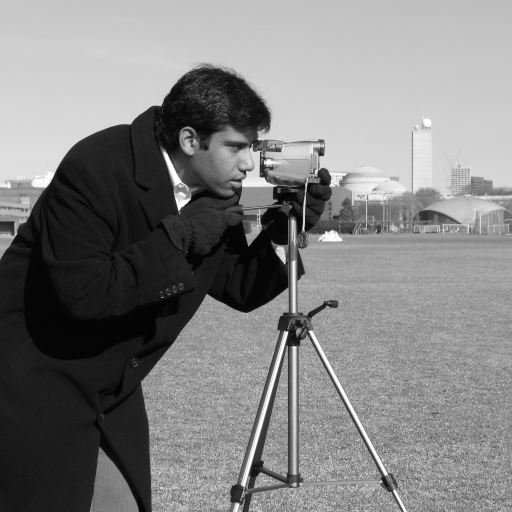

In [2]:
img = load(joinpath(CHEME5800_L7A_DATA, "camera.png")) # load the grayscale image from the data folder

Next, let's convert the image into grayscale values using [the `convert(...)` function](https://docs.julialang.org/en/v1/base/base/#Base.convert) in the Julia standard library.

> __Strange syntax alert!__ We use the `convert.` syntax to apply the conversion to every image element (similar to using `Gray.` to convert to grayscale). This is called a [vectorized dot operation](https://docs.julialang.org/en/v1/manual/mathematical-operations/#man-dot-operators) that applies a transformation to each element of the array. It's a shortcut instead of writing a loop.

We save the grayscale image matrix in the `image_array` variable.

In [3]:
image_array = convert.(Float64, Gray.(img)) # convert the image to an array of floats

512×512 Matrix{Float64}:
 0.784314   0.784314   0.784314   0.784314   …  0.741176  0.745098  0.745098
 0.784314   0.780392   0.780392   0.784314      0.745098  0.745098  0.745098
 0.780392   0.780392   0.780392   0.784314      0.745098  0.745098  0.745098
 0.784314   0.784314   0.780392   0.780392      0.745098  0.745098  0.745098
 0.784314   0.784314   0.784314   0.784314      0.74902   0.745098  0.74902
 0.784314   0.780392   0.780392   0.784314   …  0.74902   0.74902   0.74902
 0.784314   0.788235   0.784314   0.784314      0.74902   0.745098  0.745098
 0.788235   0.784314   0.784314   0.784314      0.74902   0.745098  0.745098
 0.784314   0.784314   0.784314   0.780392      0.745098  0.745098  0.74902
 0.784314   0.784314   0.780392   0.784314      0.745098  0.745098  0.745098
 ⋮                                           ⋱            ⋮         
 0.0941176  0.0980392  0.0980392  0.0941176     0.694118  0.643137  0.611765
 0.0941176  0.0941176  0.0901961  0.0901961     0.6       0.70

We now have the `image_array::Array{Float64,2}` matrix, which represents the grayscale values of the image. Each element in the matrix corresponds to a pixel in the image, with values ranging from `0.0` (black) to `1.0` (white).

___

## Task 1: Let's decompose the image using SVD
In this task, we decompose the image matrix into its singular value components using Singular Value Decomposition (SVD).

> __How?__ We'll use [the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.SVD) from the LinearAlgebra package to compute the singular value decomposition of `image_array::Array{Float64,2}`. We could have written this ourselves, but it's convenient to use the built-in function.

This produces the `U`, `Σ`, and `V` matrices, holding the left singular vectors, the singular values, and the right singular vectors, respectively.

In [4]:
(U,Σ,V) = svd(image_array); # compute the SVD of the image

In [5]:
Σ

512-element Vector{Float64}:
 278.2981758381083
  66.88074931294841
  52.215296480748755
  34.65652737982292
  23.037742722246556
  17.062534482452286
  14.623841671814565
  13.626975012428183
  13.379769202251444
  11.88499696482091
   ⋮
   0.0030489004439326665
   0.002574261315826627
   0.0022586114702942304
   0.001914199001254408
   0.0016051060495570026
   0.0013613913269967747
   0.0007150566370387086
   0.0004413496278537894
   2.3493125818876473e-5

Let's check some of the properties of the matrices produced by the SVD. First, `U` and `V` are orthogonal matrices.

> __Test:__ The columns of `U` are orthogonal unit vectors, and so are the columns of `V`. 
> Thus, $\mathbf{U}^\top \mathbf{U} = \mathbf{I}$ and $\mathbf{V}^\top \mathbf{V} = \mathbf{I}$, where $\mathbf{I}$ is the identity matrix, i.e., the dot product of any pair of different columns is zero, and the dot product of each column with itself is one.

In the code block below, we compute the products and check if they are (approximately) equal to the identity matrix using [the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) in the Julia standard library. If the assertion fails, [an `AssertionError`](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) will be raised.

This code compares each product with [the `I` constant](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.I) from the LinearAlgebra package, which stands for an identity matrix of whatever size the comparison needs.

In [6]:
let

    # compute the product -
    P₁ = transpose(U) * U;
    P₂ = transpose(V) * V;

    # check: both P₁ and P₂ should be identity matrices
    @assert isapprox(P₁, I) && isapprox(P₂, I)
end

Next, `Σ` should be a matrix with sorted values (largest to smallest). Is that what we see? Hmmm. Not quite. By default, [the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.SVD) returns a __sorted vector__, not a diagonal matrix.

We can use [the `diagm(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.diagm) to generate a diagonal matrix `ΣM` from the `Σ` vector.

In [7]:
ΣM = Σ |> m-> diagm(m) # convert the Σ vector to a diagonal matrix

512×512 Matrix{Float64}:
 278.298   0.0      0.0      0.0     …  0.0          0.0         0.0
   0.0    66.8807   0.0      0.0        0.0          0.0         0.0
   0.0     0.0     52.2153   0.0        0.0          0.0         0.0
   0.0     0.0      0.0     34.6565     0.0          0.0         0.0
   0.0     0.0      0.0      0.0        0.0          0.0         0.0
   0.0     0.0      0.0      0.0     …  0.0          0.0         0.0
   0.0     0.0      0.0      0.0        0.0          0.0         0.0
   0.0     0.0      0.0      0.0        0.0          0.0         0.0
   0.0     0.0      0.0      0.0        0.0          0.0         0.0
   0.0     0.0      0.0      0.0        0.0          0.0         0.0
   ⋮                                 ⋱               ⋮           
   0.0     0.0      0.0      0.0        0.0          0.0         0.0
   0.0     0.0      0.0      0.0        0.0          0.0         0.0
   0.0     0.0      0.0      0.0     …  0.0          0.0         0.0
   0.0     0

If we compute the matrix product $\mathbf{U}\mathbf{Σ}\mathbf{V}^\top$, we should get back our original image matrix (approximately, due to numerical precision issues). Let's check this.

In [8]:
let
    reconstructed = U * ΣM * transpose(V);
    @assert isapprox(reconstructed, image_array)
end

Ok, so our decomposition seems to be correct. Let's move on to the next task. 
___

## Task 2: Compute the frames and store them in a dictionary
In this task, we compute the frames of the image, store them in a dictionary, and measure how well the first few frames rebuild the image. 

> __Data reduction__
>
> Singular value decomposition (SVD) can be thought of as decomposing a matrix into a weighted, ordered sum of separable matrices, e.g., frames of a larger image. Let $\mathbf{A}\in\mathbb{R}^{m\times{n}}$ have the singular value decomposition $\mathbf{A} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^{\top}$. Then, the matrix $\mathbf{A}$ can be written as:
>
> $$
> \begin{align*}
> \mathbf{A} &= \sum_{i=1}^{r({\mathbf{A}})}\sigma_{i}\cdot\underbrace{\left(\mathbf{u}_{i}\otimes\mathbf{v}_{i}\right)}_{\mathbf{A}_{i}}
> \end{align*}
> $$
> where $r({\mathbf{A}})$ is the rank of matrix $\mathbf{A}$, the vectors $\mathbf{u}_{i}$ and $\mathbf{v}_{i}$ are the $i$-th left and right singular vectors, and $\sigma_{i}$ are the ordered singular values. The [outer product](https://en.wikipedia.org/wiki/Outer_product) $\mathbf{A}_{i} = \left(\mathbf{u}_{i}\otimes\mathbf{v}_{i}\right)$ is a separable rank-one component of the matrix $\mathbf{A}$.

Ok, so let's do this decomposition and see what this sum looks like. First, we compute the rank $r(\mathbf{A})$ of `image_array` using [the `rank(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank) and then calculate the individual frames $\sigma_{i}\,\mathbf{A}_{i}$ of the image by computing the [outer product](https://en.wikipedia.org/wiki/Outer_product) of the left and right singular vectors.

We use [the `foreach(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.foreach) as a shortcut means of populating the `image_frames_dictionary` variable. We could have used a regular for loop. But let's go crazy!

In [9]:
image_frames_dictionary = let

    # initialize -
    image_frames_dictionary = Dict{Int64,Matrix{Gray{Float64}}}();

    R = rank(image_array); # how many frames will we have?
    foreach(i -> image_frames_dictionary[i] = Σ[i]*⊗(U[:,i],V[:,i]), 1:R); # another iteration pattern???

    image_frames_dictionary; # return
end

Dict{Int64, Matrix{Gray{Float64}}} with 512 entries:
  56  => [-2.32316e-5 -2.65105e-5 … 5.1501e-5 3.8716e-6; -9.30999e-5 -0.0001062…
  35  => [7.74614e-5 -0.000154103 … -3.21802e-5 0.000205629; 7.39727e-5 -0.0001…
  425 => [-1.26109e-5 1.69387e-6 … 2.64e-6 1.3131e-5; 7.06384e-5 -9.48799e-6 … …
  429 => [7.0904e-6 -9.46315e-6 … -5.91643e-5 -7.03447e-5; -1.54547e-5 2.06265e…
  60  => [-0.000214596 -0.00020045 … -7.05074e-5 -7.43359e-5; -0.000298132 -0.0…
  220 => [2.60346e-6 3.22159e-6 … 2.88031e-6 4.79629e-8; 2.55264e-5 3.15871e-5 …
  308 => [-7.51271e-5 -3.20886e-5 … 1.22667e-5 4.31464e-5; -0.000240694 -0.0001…
  67  => [1.4891e-5 1.66152e-5 … 4.55919e-6 -5.87901e-5; -1.44793e-7 -1.61559e-…
  215 => [4.36514e-5 3.09192e-5 … -1.27086e-5 -3.11514e-5; -0.000219186 -0.0001…
  73  => [0.000184707 0.000172453 … 1.013e-5 5.43947e-6; 0.000233739 0.00021823…
  319 => [0.000273225 -8.28977e-5 … -3.0661e-5 0.000387866; 0.000176772 -5.3633…
  251 => [-3.6226e-5 6.23209e-5 … -0.000114571 -2.84929e

What is the rank of the `image_array::Array{Float64,2}`? The rank is given by the number of non-zero singular values in its singular value decomposition (SVD).

In [10]:
R = rank(image_array)

512

### Not every frame contains the same amount of information
One of the cool things about [singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) is that frames are sorted and weighted by the singular values. Thus, we can compute the contribution of each frame by looking at the singular values.

Let's compute and visualize how close the image built from the first $k$ frames, $\hat{\mathbf{A}}_{k}=\sum_{i=1}^{k}\sigma_{i}\mathbf{A}_{i}$, is to the original image $\mathbf{A}$. We measure the gap with the [Frobenius norm](https://en.wikipedia.org/wiki/Matrix_norm#Frobenius_norm), the square root of the sum of the squared entries of a matrix. For the reconstruction error, we square the pixel-by-pixel differences, add them, and take the square root.

Each frame $i$ contributes $\sigma_{i}^{2}$ to the squared Frobenius norm of the image, $\|\mathbf{A}\|_{F}^{2}=\sum_{i}\sigma_{i}^{2}$. Thus, the relative error of $\hat{\mathbf{A}}_{k}$ comes from the singular values of the frames we left out:

$$
e_{k} = \frac{\|\mathbf{A}-\hat{\mathbf{A}}_{k}\|_{F}}{\|\mathbf{A}\|_{F}} = \sqrt{\frac{\sum_{i=k+1}^{r(\mathbf{A})}\sigma_{i}^{2}}{\sum_{i=1}^{r(\mathbf{A})}\sigma_{i}^{2}}}
$$

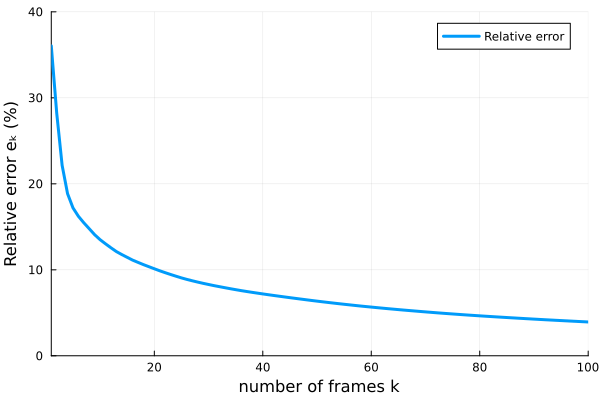

In [11]:
let
    
    # make a plot of the relative error of the image built from the first k frames
    number_of_modes = length(Σ);
    ΣS = (1/sum(Σ.^2))*(Σ.^2); # fraction of the squared Frobenius norm carried by each frame
    error_array = [100*sqrt(sum(ΣS[(k+1):end])) for k ∈ 1:number_of_modes]; # comprehension, sums over the frames we left out

    plot(error_array, label="Relative error", lw=3)
    xlabel!("number of frames k", fontsize=18)
    ylabel!("Relative error eₖ (%)", fontsize=18)
    xlims!(1, 100) # show the first 100 frames
    ylims!(0, 40) # start the error axis at zero
end

With no frames the error is 100%, and one frame already brings it down to about 36%. We did not subtract the average pixel value before the SVD, so the first frame mostly holds the image's average brightness. The later frames add edges and finer detail: 10 frames give about 13.5% error, 20 frames give about 10%, and 100 frames give about 4%. We add up the frames and look at the rebuilt image in Task 3.

___

## Task 3: Reconstruct the image from its frames
In this task, we add up the frames to rebuild the image, and then check the rank of the result.

### Can we rebuild the image from its first few frames?
Let's try to rebuild the original image by adding up the frames. Since the original image is just a matrix, we can use the structural decomposition idea to do this.

> __Idea:__ Grab the first frame from the `image_frames_dictionary` and set this to the `M` variable. Then, iterate through the collection up to a specified `number_of_frames`, where we update the `M` variable each time through the loop with the next frame. This should approximate the original image, one rank unit at a time. Mind blown!

So what do we see?

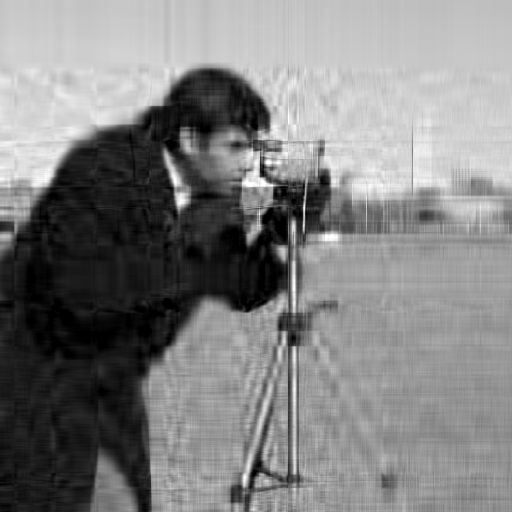

In [12]:
M = image_frames_dictionary[1];
number_of_frames = 20;
for i ∈ 2:number_of_frames
    M += image_frames_dictionary[i]
end
M # this will show the reconstructed image

With 20 frames, the cameraman and tripod are easy to recognize, but the sky and grass show horizontal and vertical streaks and the buildings are blurred. The error plot in Task 2 puts this image at about 10% relative error. If you change `number_of_frames`, your image and error will change too.

### What is the rank of the matrix blocks being added together?
Recall that the rank of a matrix is the number of linearly independent rows (or columns) in a matrix. Singular value decomposition gives us another way to think about rank: it is a measure of the unique information held by the matrix, i.e., the number of rank-one blocks!

> __Idea.__ Let's check out this alternative notion of rank. If we reconstruct the matrix by adding frames together, the rank of the resulting matrix will be equal to the number of frames being added, i.e., the `number_of_frames` variable that we specified. This works because the left singular vectors of the frames are orthogonal to each other, and so are the right singular vectors.

Let's check this by computing the rank of the `M` matrix using [the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert).

In [13]:
@assert rank(M) == number_of_frames

Wow!
___

## Summary

In this example, we learned how SVD breaks down complex matrices into ranked components that reveal the underlying structure of information.

> __Key Takeaways:__
>
> * __The SVD splits an image into ranked frames:__ We factored the image matrix into left singular vectors, singular values, and right singular vectors, and checked that multiplying them back together returns the image. Each singular value weights one rank-one frame, and the frames come sorted from largest to smallest weight.
> * __A few frames rebuild a recognizable image:__ We measured the relative error of the image built from the first few frames and found that it falls quickly and then levels off. With 20 of the 512 frames, the error is about 10% and the cameraman and tripod are easy to recognize.
> * __The number of frames sets the rank:__ We added up the first few frames and checked that the rank of the sum equals the number of frames. This works because the singular vectors of different frames are orthogonal, so each new frame raises the rank by one.

Through this hands-on exploration, we verified SVD's mathematical properties and demonstrated how rank-one components can reconstruct complex data.

___